**Next token prediction** 

* *Input* : "To be or not to " 
* *Target Output* : "be"

I already have a trained model right ? 

So training on this model, even a full fledged training would amount to :- 
* Continued pretraining or Domain Pretraining 
* The model I have taken is already trained 
* I will be training it *further* on a new corpus 

During this next token prediction 
* Model internally shifts labels 
* Input ID : [To, be, or, not, to]
* Labels : [be, or, not, to, <next>]

# Next Token Prediction
* Causal Language Model (CLM)

In [48]:
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
from transformers import pipeline
import torch
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
dataset_id = "Trelis/tiny-shakespeare" 
cache_dir = "data_folder" 

dataset = load_dataset(dataset_id, 
                       cache_dir = cache_dir)

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})


In [3]:
model_id = "distilbert/distilgpt2"

* Batching requires sequences of equal length 
* GPT Models do not have any padding token, only eos tokens. 
* Hence reusing eos as pad
* Think GPT2 uses **byte paior encoding** *BPE*
* Bad padding will give us the wrong loss --> unstable gradients

In [4]:
tokenizer = AutoTokenizer.from_pretrained(model_id, 
                                          cache_dir = "models")
tokenizer.pad_token = tokenizer.eos_token

def tokenize_function(examples):
    return tokenizer(examples["Text"])

#Something like "hello are you" ---> [222, 12, 312]
# map(function, iterable) --- Aplies the function to every element in the iterable and returns the map object (iterator)

tokenized_dataset = dataset.map(
    tokenize_function,
    batched = True, 
    remove_columns = ["Text"]
)

* Convert tokens from lets say [token1, token2, token3, ....token10000] to 
* [token1....token128], [token129....tokenm256]
* Each [...] is a **block** 
* Block size is very important. Smaller the faster and less context, larger the heavier and more context

In [5]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 472
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 49
    })
})

* HF datasets are values inside "keys"
* Backed by apache arrow allowing data to be stored in such a way on the drive that it can be ready instantly without loading the whole file on memory

In [6]:
block_size = 128 

def group_texts(batch):
    '''
    Each batch should be a list of lists ? 
    Each batch will have "input_ids", "attention_mask" 
    batch["input_ids"] = [[id1], [id2]....]
    '''

    #Combine all tokens from all sentences in the batch to one long list
    concatenated = {}
    for key in batch.keys():
        mega_list = [] 
        for individual_sentence in batch[key]:
            for token in individual_sentence:
                mega_list.append(token)
        concatenated[key] = mega_list

    #Calculate number of full blocks of each block size we can make 
    total_length = len(concatenated["input_ids"])
    total_length = (total_length // block_size) * block_size #The remainder is dropped 
    
    #Chunking - Cut the megalist into exact block sizes 
    result = {} 
    for key in concatenated.keys():
        all_tokens = concatenated[key]
        list_of_blocks = []

        for i in range(0, total_length, block_size):
            chunk = all_tokens[i : block_size+i]
            list_of_blocks.append(chunk)
        result[key] = list_of_blocks 

    return result 

lm_dataset = tokenized_dataset.map(
    group_texts, 
    batched = True
)

    


* If you look at the code it ll look like we are creating chunks for the "input_ids" and "attention_mask" for each batch being sent to the function.
* Lets say one batch has been sent then we take all the tokens for the input_ids and masks then create chunks with the exact block size we have specified. 
* Once for each key. 
* The main engineering is with the mapping function. It handles and catches the values from the return and appends them to a new list in the background one by one. Once all batches have been sent it returns this new "list" data.

In [7]:
lm_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 2880
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask'],
        num_rows: 302
    })
})

In [ ]:
model = AutoModelForCausalLM.from_pretrained(model_id, 
                             cache_dir = "models", 
                             attn_implementation = "eager") #By default attention is sdpa, so more optimised but wont show the full attn mask output which I want for this demo

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

* Transformer decoder stack 
* Self attention layers 
* LLM Head (predict next token) 
* model output logits - [batch_size, seq_len, vocab_size]

In [33]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer = tokenizer, 
    mlm = False
)

* Dynamically pads batches 
* Creates labels by shifting inputs 

In [34]:
training_args = TrainingArguments(
    output_dir = "results", 
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8, 
    num_train_epochs = 3,
    fp16 = True,
    logging_steps = 50, 
    save_steps = 500,
    learning_rate = 5e-5, 
    report_to = "none"
)

#effective batch size should be 2x8 = 16 

In [35]:
trainer = Trainer(
    model = model, 
    args = training_args, 
    train_dataset = lm_dataset["train"],
    data_collator = data_collator
)

trainer.train()

Step,Training Loss
50,4.211159
100,3.961346
150,3.853807
200,3.768384
250,3.705126
300,3.676161
350,3.657598
400,3.627709
450,3.591161
500,3.594735


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=540, training_loss=3.7520992420337818, metrics={'train_runtime': 152.7534, 'train_samples_per_second': 56.562, 'train_steps_per_second': 3.535, 'total_flos': 282200490639360.0, 'train_loss': 3.7520992420337818, 'epoch': 3.0})

In [12]:
generator = pipeline("text-generation",
                     model = model, 
                     temperature = 0.0001,
                     tokenizer = tokenizer)

print(generator("Thou art a very ", max_new_tokens = 128)[0]["generated_text"])

Passing `generation_config` together with generation-related arguments=({'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=128) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Thou art a very ilere,
And I'll be the first to die.

DUKE VINCENTIO:
I'll be the first to die.

DUKE VINCENTIO:
I'll be the first to die.

DUKE VINCENTIO:
I'll be the first to die.

DUKE VINCENTIO:
I'll be the first to die.

DUKE VINCENTIO:
I'll be the first to die.

DUKE VINCENTIO:
I'll be the first to die.



* Transformers archttectures will depend on the task 
* Encoder only 
    * BERT
    * Classification, embeddings 
    * Read sentence bidirectionally 

* Decoder Only 
    * GPT2
    * Text Generation
    * USes causal masking (cannot see future tokens)

* Encoder - Decoder 
    * T5
    * Translation, summarisation

**Token Flow - For the text being sent** | **Core Mechanism**

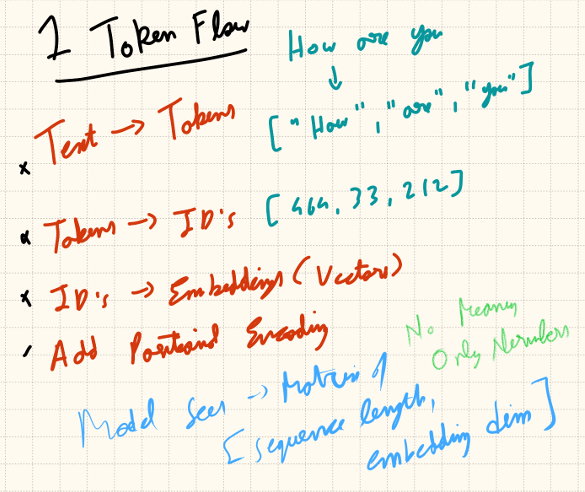 | 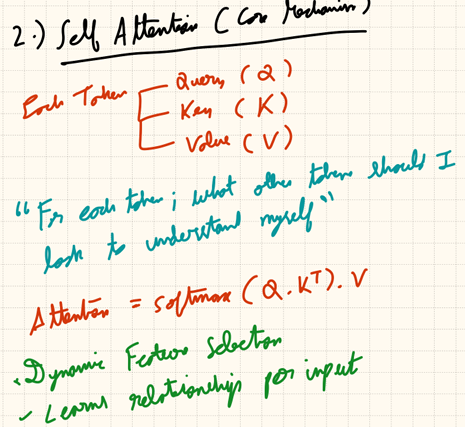

**Causal Masking - Making it learn what to predict or complete next** 

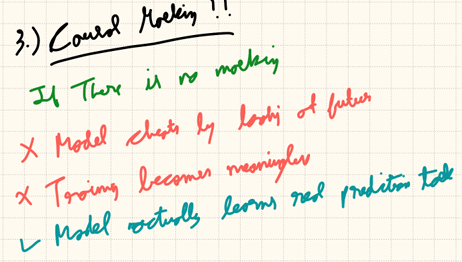 | 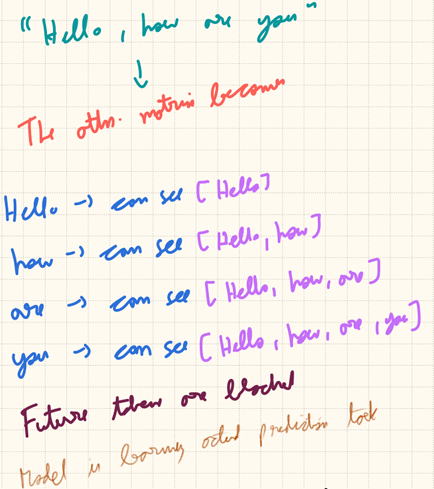

**Transformers Layers** 

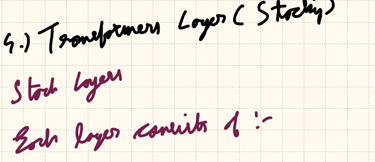 | 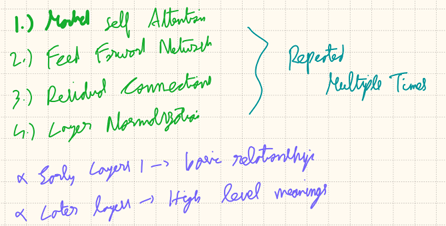 

**Logits - Prediction Layer** | **Loss Computation** | **Backpropagation** 

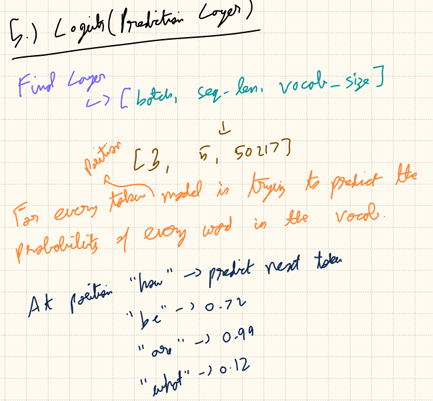 | 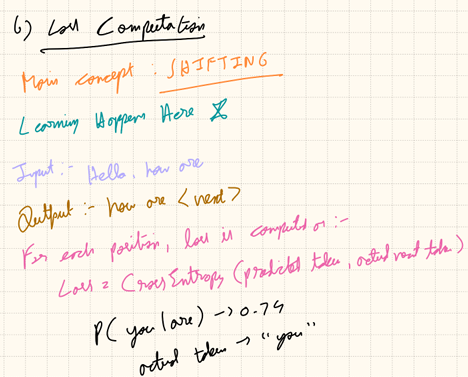 | 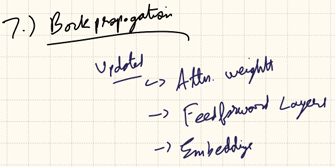

**Gist of current flow** 

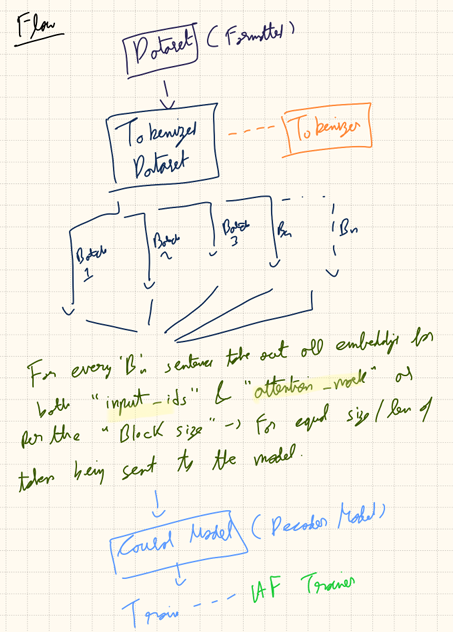

* Text 
    * -> Tokens
    * -> Embeddings 
    * -> Masked self-attn 
    * -> Transformers layers 
    * -> Logits 
    * -> Cross Entropy Loss 
    * -> Backpropagation 

* So technically it is not just predicting the next word. It is also learning the *probability distribiution over the language* 
* This makes it
    * generate text
    * mimic style 
    * Complete answers... i mean sentences 
    * Reason ... but only to an extent ... I need to go a lot more deeper for this *reasoning* 

* Each Head -> Head1(Q1,K1,V1), Head2(Q2, K2, V2), Head3(Q3, K2, V2)
* One head can only focus on one relationship at a time 
* Multiple heads allow *parallel relationship discovery* 

* Every head is random.. No specialization 
* Gradient descent and backpropogation forces them to understand the structure of the data 
* Randomly, different heads receive different signals. Loss, gradients push them towards different directions
* In an analogy different heads are like differnet developers who start at the same but end up learning or specializing in different domains
    * Syntax Heads
    * Positional Heads 
    * Long range dependency heads 
    * Copy / repetition heads 
    * Rare keywords heads 

> Is the design of the transformers such that MHA is not by accident ? 

> If different heads do different things then why not prune the ones not needed when it comes to specialized tasks ? 

# Viz Analysis

In [36]:
model.config.output_attentions

False

In [51]:
device = ''
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    

sentence = "The cat sat on the bat or the mat"

inputs = tokenizer(sentence, 
                   return_tensors = "pt").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

model.config.output_attentions = True
model = model.eval()
#Forward pass with ATTENTION 
outputs = model(**inputs, output_attentions = True)
attentions = outputs.attentions #Should be (num_layers) x (batch, num_heads, seq_len, seq_len) 

In [52]:
model.config.output_attentions

True

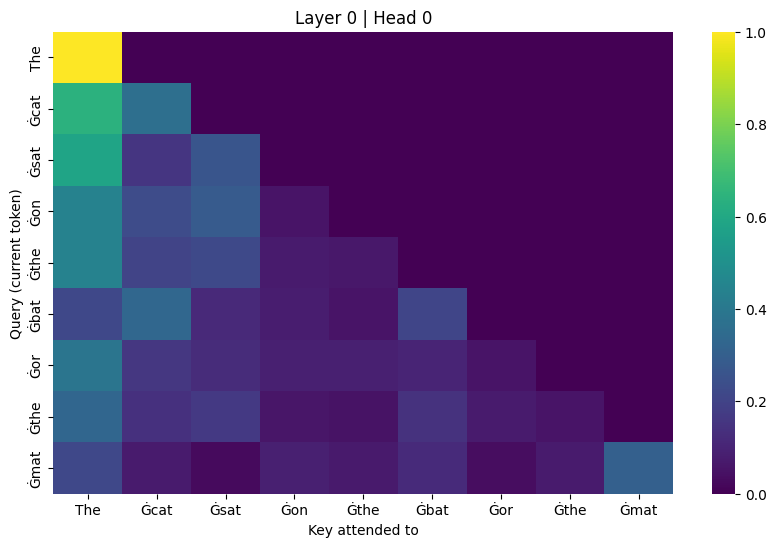

In [62]:
layer_number = 0
head_number = 0
attention_matrix = attentions[layer_number][0, head_number].cpu().detach().numpy()

plt.figure(figsize = (10,6))
sns.heatmap(attention_matrix,
            xticklabels = tokens, yticklabels = tokens, 
            cmap = "viridis") 
plt.title(f"Layer {layer_number} | Head {head_number}")
plt.xlabel("Key attended to")
plt.ylabel("Query (current token)")
plt.show()

* Diagonals should be strong, dominant. Token attends to itself 
* Look at the off diagonal relationships which are strong too

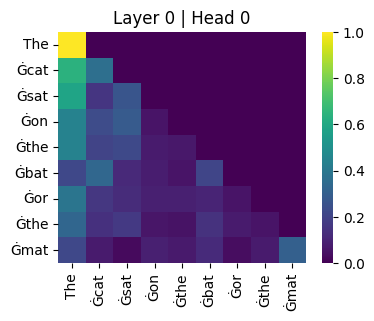

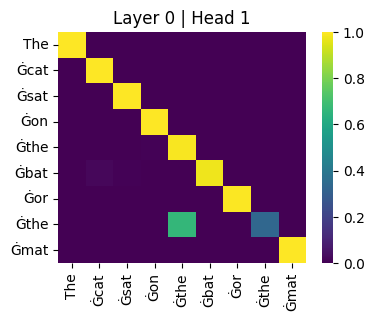

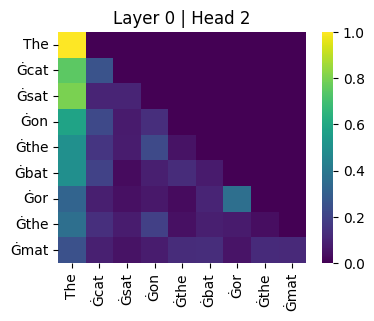

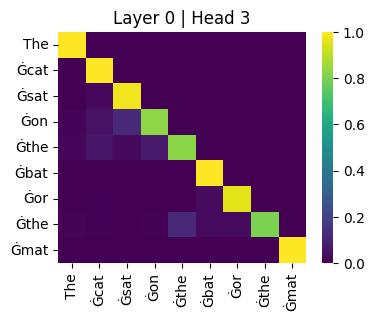

In [66]:
for head_number in range(4):
    plt.figure(figsize=(4,3))
    attention_matrix = attentions[0][0, head_number].cpu().detach().numpy()
    sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
    plt.title(f"Layer 0 | Head {head_number}")

* Same layer - different heads
* Different patterns 
* Different tokens - each head focuses on
* General consensus
    * EArly layers - Positional attentions, near tokens
    * Middle layers - Grammar relationships 
    * Later layers - Meaning and grouping 

> Compare the attentions before and after training\fine-tuning 

<Axes: >

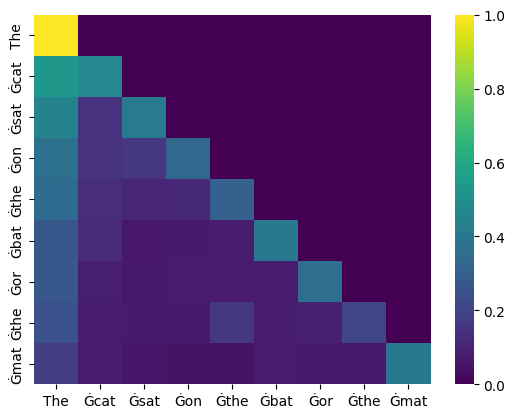

In [73]:
avg = attentions[0][0].mean(dim=0).cpu().detach().numpy() 
sns.heatmap(avg, xticklabels=tokens, yticklabels=tokens, cmap="viridis")

* Attention does not directly output words
* Controls what the model knows at "each" position
* Attn decies -> information flow -> shapes hidden states -> determines logits -> determines next token
* Attention(Q, K, V) = softmax(QKᵀ) · V 
* Attention weights is not equal to the output, they are just the coefficients 
* The real output is *weighted sum of VALUE vectors* 
* Lets say for "hello" ->    0.6 x V("hello") + 0.3 x V("are")
* Mutli head + projection -> Each head produces its own output -> concat -> linear projection + final representation
* Feedforward -> richer representation 
* hidden state -> linear layer -> logits 
* softmax(logits)

* if the sentence is something like 'hello how are you' 
* It should understand the context behind this sentence like maybe using hello and you.
* So the logits should favour a reply of another greeting -> case of good attention -> return things like "fine", "good", "happy"
* if attention ignores "how" and/or "you" it ll be a case of -> bad attention 

> Attention determines *what context is available to make prediciton*


> Next time I train a mode, check which head is important for the task and/or data ?